# From Knowledge Graphs to Cheese: Exploring Microbial Habitats with Python

**Hands-on lesson – ~2 hours**

---

## Learning goals

By the end of this lesson you will be able to:

1. Load and explore a real biological dataset in Python with **pandas**
2. Understand what a **knowledge graph** is and represent it as a list of *triples*
3. Build and inspect graphs with **NetworkX**
4. Build a habitat-habitat network directly from microorganism-habitat associations
5. Weight habitat links with degree normalization ($1/k$)
6. Identify and visualise the sub-network of **cheese habitats**

---

## The data: OmniCrobe / BacDive habitat relations

We will use a text file extracted from **OmniCrobe**, a resource that integrates microbiology data from multiple databases.  
Each row in the file records that a scientific paper mentions a **microorganism** living in a specific **habitat**.

```
microorganism  ──has_habitat──▶  habitat
```

Both the microorganism and the habitat are identified by ontology/taxonomy IDs, and the file also contains their full taxonomic/ontological **paths** (parent -> child relationships).

---

## What is a Knowledge Graph?

A **knowledge graph** stores facts as **triples**:  
*(subject, relation, object)*

For example:
- `(ncbi:1234, has_habitat, OBT:001480)` -> *"bacterium 1234 lives in cheese"*
- `(ncbi:1234, is_a_organism, ncbi:91061)` -> *"bacterium 1234 is a Bacilli"*
- `(OBT:001480, is_a_habitat, OBT:000500)` -> *"cheese is a type of dairy product"*

These triples together form a graph where **nodes** are entities and **edges** are relations.

---
## Step 0 – Import libraries

We need a few standard libraries. Run this cell before anything else.

In [38]:
import os
import pandas as pd          # data manipulation (tables)
import networkx as nx         # graph data structures and algorithms
import matplotlib.pyplot as plt  # basic plotting
from collections import Counter  # counting occurrences
from tqdm import tqdm         # progress bars for slow loops

print("All libraries imported successfully!")

# Helper functions
def prune_to_dag_by_scc(G):
    """
    Make a copy of G and prune edges so that the result is a DAG.
    Inside each strongly connected component, keep only a spanning tree of edges.
    """
    G = G.copy()
    sccs = list(nx.strongly_connected_components(G))

    for comp in tqdm(sccs):
        if len(comp) <= 1:
            continue
        sub = G.subgraph(comp).copy()

        ## pick as root the node with the highest out-degree in the subgraph
        ## (in parent→child direction, parents have higher out-degree)
        root = max(sub.nodes(), key=lambda n: sub.out_degree(n))

        ## pick as root one random node
        #root = next(iter(sub.nodes()))

        # tree_edges is a set of edges forming a spanning tree inside the SCC
        tree_edges = set(nx.bfs_edges(sub, root))

        # remove all internal edges that are not part of this tree
        for u, v in sub.edges():
            if (u, v) not in tree_edges:
                G.remove_edge(u, v)

    # After removing cycles inside SCCs, the whole graph must be a DAG
    assert nx.is_directed_acyclic_graph(G)
    return G

All libraries imported successfully!


---
## Step 1 – Load the data

The file `PubMed_Habitat_Relations.txt` is a **tab-separated** table with no header row.  
Each row is one mention of a microbe–habitat association found in a PubMed publication.

We manually give names to the columns based on the documentation.

In [140]:
# Load the file into a pandas DataFrame
# sep='\t' means the columns are separated by a TAB character
# header=None means there is no header row in the file
# data = pd.read_csv('data/PubMed_Habitat_Relations_2025.txt', sep='\t', header=None)

from io import StringIO
import re, html, requests

# Google Drive shared URL -> direct download URL for pandas
shared_url = 'https://drive.google.com/file/d/1AouaZNO8GO9G33dQZnyxLqyVrHiFa7jh/view?usp=share_link'
file_id = shared_url.split('/d/')[1].split('/')[0]
url = f'https://drive.google.com/uc?export=download&id={file_id}'

data = pd.read_csv(url, sep='\t', header=None)
if data.shape[1] == 1:  # Drive returned HTML (virus-scan/confirm page)
    s = requests.Session()
    r = s.get(url)
    action = re.search(r'id="download-form"[^>]*action="([^"]+)"', r.text)
    hidden = dict(re.findall(r'name="([^"]+)" value="([^"]*)"', r.text))
    if action and hidden:
        r = s.get(html.unescape(action.group(1)), params=hidden)
        data = pd.read_csv(StringIO(r.text), sep='\t', header=None)

if data.shape[1] == 1:
    raise RuntimeError('Google Drive non ha restituito un TSV. Verifica che il file sia condiviso come "Anyone with the link".')

# Assign descriptive column names
data.columns = [
    "sub_batch",       # source batch identifier
    "pub_id",          # PubMed publication ID
    "source_type",     # type of source (PubMed, etc.)
    "mic_ncbi_id",     # microorganism NCBI taxonomy ID  (e.g. 'tax:1234')
    "mic_ent1",        # microorganism entity string 1 (raw text from paper)
    "mic_ent2",        # microorganism entity string 2
    "mic_norm_ent",    # microorganism normalized name
    "mic_ncbi_path",   # full taxonomic path for the microorganism
    "pheno_onto_id",   # habitat ontology ID (OntoBiotope, e.g. 'OBT:001480')
    "pheno_ent1",      # habitat entity string 1
    "pheno_ent2",      # habitat entity string 2
    "pheno_norm_ent",  # habitat normalized name
    "pheno_onto_path", # full ontology path for the habitat
]

# In case of BacDive dataset
# data.columns = [
#     "mic_ent",        # microorganism entity string 1 (raw text from paper)
#     "mic_norm_ent",    # microorganism normalized name
#     "mic_ncbi_id",     # microorganism NCBI taxonomy ID  (e.g. 'tax:1234')
#     "mic_ncbi_path",   # full taxonomic path for the microorganism
#     "pheno_ent",      # habitat entity string 1
#     "pheno_onto_id",   # habitat ontology ID (OntoBiotope, e.g. 'OBT:001480')
#     "pheno_norm_ent",  # habitat normalized name
#     "pheno_onto_path", # full ontology path for the habitat
#     "bd_dsms_id"       # DSMZ dataset ID
# ]

print(f"Dataset shape: {data.shape[0]} rows x {data.shape[1]} columns")
data.head()

Dataset shape: 700450 rows x 13 columns


,sub_batch,pub_id,source_type,mic_ncbi_id,mic_ent1,mic_ent2,mic_norm_ent,mic_ncbi_path,pheno_onto_id,pheno_ent1,pheno_ent2,pheno_norm_ent,pheno_onto_path
0,0,"38183791, 31120677, 34411997, 25481056, 144439...",title,ncbi:1639,"CFU of L. monocytogenes, L. monocytogenes, Lis...","L._monocytogene ATCC_7644, Listeria_Monocytoge...",Listeria monocytogenes,/ncbi:1/ncbi:131567/ncbi:2/ncbi:1783272/ncbi:1...,OBT:000008,"certain RTE foods, ready-to-eat aquatic foods,...","fish - processed food product, asparagus model...",food,/OBT:000001/OBT:000008
1,0,"1750966, 21219765, 21142945, 24468028, 3249779...",abstract,ncbi:1639,"F2365, Listeria monocytogenes WSLC 1364, CFU o...","F2365, L._monocytogene serogroup 4b, Listeria_...",Listeria monocytogenes,/ncbi:1/ncbi:131567/ncbi:2/ncbi:1783272/ncbi:1...,OBT:001480,"Graviera cheese, Baladi cheese, interior sampl...","soft lactic cheese, surface of Minas Frescal c...",cheese,/OBT:000001/OBT:000008/OBT:000094/OBT:000240/O...
2,0,"21219765, 16541704, 31655547, 17462773, 124306...",abstract,ncbi:1639,"L. monocytogenes, Listeria monocytogenes NCTC1...","L_monocytogenes, Listeria_monocytogene ATCC_76...",Listeria monocytogenes,/ncbi:1/ncbi:131567/ncbi:2/ncbi:1783272/ncbi:1...,OBT:001200,"minced meat products, various meat samples, me...","retail meat product, vacuum - packaged meat pr...",meat and meat product,/OBT:000001/OBT:000008/OBT:000094/OBT:000240/O...
3,0,"29342189, 33397610, 22225983, 29157822, 194652...",title,ncbi:83334,"Escherichia coli O157:H7 NCTC 12900, STEC, Esc...","STEC, Escherichia_coli_O157:H7 NCTC_12900, ECO...",Escherichia coli O157:H7,/ncbi:1/ncbi:131567/ncbi:2/ncbi:3379134/ncbi:1...,OBT:000054,"Biofilms, multispecies biofilms, higher anti-b...","single - species biofilm, dimensional biofilm ...",biofilm,/OBT:000001/OBT:000012/OBT:000054
4,0,"18810858, 33108462, 14968961, 17803136, 146272...",abstract,ncbi:83334,Escherichia coli O157:H7,Escherichia_coli_O157:H7,Escherichia coli O157:H7,/ncbi:1/ncbi:131567/ncbi:2/ncbi:3379134/ncbi:1...,OBT:001557,"beef processing plants, plants, plant, multipl...","Midwestern fed-beef processing plant, food - p...",food processing factory,/OBT:000001/OBT:000006/OBT:000100/OBT:000324/O...


### 1.1 – Understand the columns

Let's look at a few key columns in more detail.

In [100]:
# How many unique microorganism IDs are there?
n_microbes = data['mic_ncbi_id'].nunique()
print(f"Number of unique microorganism IDs: {n_microbes}")

# How many unique habitat IDs are there?
n_habitats = data['pheno_onto_id'].nunique()
print(f"Number of unique habitat IDs: {n_habitats}")

# How many unique publications contributed data?
n_pubs = data['pub_id'].nunique()
print(f"Number of unique publications: {n_pubs}")

Number of unique microorganism IDs: 62329
Number of unique habitat IDs: 2986
Number of unique publications: 464710


In [101]:
# Look at what a microorganism path looks like
# This shows the full taxonomic lineage from root to that organism
print("Example microorganism path:")
print(data['mic_ncbi_path'].iloc[0])

print()

print("Example habitat path:")
print(data['pheno_onto_path'].iloc[0])

Example microorganism path:
/ncbi:1/ncbi:131567/ncbi:2/ncbi:1783272/ncbi:1239/ncbi:91061/ncbi:1385/ncbi:186820/ncbi:1637/ncbi:1639

Example habitat path:
/OBT:000001/OBT:000008


### 1.2 – Build lookup dictionaries (ID → human-readable name)

The IDs like `OBT:001480` are not easy to read. We build two dictionaries so we can always look up the real name.

In [102]:
# Create a dictionary: NCBI taxonomy ID  →  normalized microorganism name
# We use only the relevant columns and drop duplicates before converting
ncbi_id_to_name = (
    data[['mic_ncbi_id', 'mic_norm_ent']]
    .drop_duplicates()
    .set_index('mic_ncbi_id')['mic_norm_ent']
    .to_dict()
)

# Create a dictionary: OntoBiotope habitat ID  →  normalized habitat name
habitat_id_to_name = (
    data[['pheno_onto_id', 'pheno_norm_ent']]
    .drop_duplicates()
    .set_index('pheno_onto_id')['pheno_norm_ent']
    .to_dict()
)

# Quick test
print("Lookup test:")
example_mic_id = data['mic_ncbi_id'].iloc[0]
print(f"  Microbe {example_mic_id}  →  {ncbi_id_to_name[example_mic_id]}")

example_hab_id = data['pheno_onto_id'].iloc[0]
print(f"  Habitat {example_hab_id}  →  {habitat_id_to_name[example_hab_id]}")

Lookup test:
  Microbe ncbi:1639  →  Listeria monocytogenes
  Habitat OBT:000008  →  food


---
## Step 2 – Build the triples

A **triple** is a tuple `(head, relation, tail)`.  
We are going to extract three kinds of triples from the data:

| Type | Meaning | Example |
|------|---------|----------------------------------------------------------|
| MH triples | microbe lives in habitat | `(ncbi:1234, has_habitat, OBT:001480)` |
| M triples | organism A is a sub-taxon of B | `(ncbi:5678, is_a_organism, ncbi:91061)` |
| H triples | habitat A is a sub-type of B | `(OBT:001480, is_a_habitat, OBT:000500)` |

### 2.1 – Microbe–Habitat triples (MH)

In [103]:
# Build one triple per row: (microbe_id, 'has_habitat', habitat_id)
# We then deduplicate because the same fact can appear many times
# (same microbe + habitat mentioned in multiple papers)

triples_MH = []  # list to collect the triples

for idx, row in tqdm(data.iterrows(), total=len(data), desc="Building MH triples"):
    head     = row['mic_ncbi_id']   # the microorganism
    relation = 'has_habitat'        # the relationship type
    tail     = row['pheno_onto_id'] # the habitat
    triples_MH.append((head, relation, tail))

# Remove duplicates by converting to a set, then back to a list
triples_MH = list(set(triples_MH))

print(f"Number of unique MH triples: {len(triples_MH)}")

# Peek at the first 5
for t in triples_MH[:5]:
    mic_name = ncbi_id_to_name.get(t[0], t[0])
    hab_name = habitat_id_to_name.get(t[2], t[2])
    print(f"  {mic_name}  →[{t[1]}]→  {hab_name}")

Building MH triples: 100%|██████████| 700450/700450 [00:07<00:00, 88333.98it/s]


Number of unique MH triples: 700450
  Pseudomonas  →[has_habitat]→  ornamental Prunus tree
  Cronobacter  →[has_habitat]→  beef
  Histoplasma capsulatum  →[has_habitat]→  fungi as food
  Leuconostoc  →[has_habitat]→  probiotic food
  Rikenellaceae  →[has_habitat]→  straw


### 2.2 – Taxonomy/Ontology hierarchy triples (M and H)

The columns `mic_ncbi_path` and `pheno_onto_path` store the full path from the root of the taxonomy (or ontology) to the entity.  
For example: `/1/131567/2/1224/28216/135614/1234/`

Each consecutive pair `(child, parent)` in this path is an `is_a` triple.  
We write a helper function to extract all such pairs from a path string.

In [104]:
def extract_is_a_triples(path_string, separator='/', relation_name='is_a'):
    """
    Given a path like '/1/131567/2/1224/', return all (child, relation, parent) triples.
    
    The path goes from root (left) to leaf (right), so:
      - nodes[0] is the most general ancestor (root)
      - nodes[-1] is the most specific entity (leaf)
    
    We strip the leading/trailing separators, then split into individual IDs.
    We filter out empty strings (which can occur if the path has consecutive separators).
    """
    # Strip leading/trailing separators and split, filtering out empty strings
    nodes = [x for x in path_string.strip(separator).split(separator) if x]

    # Build one triple per consecutive pair
    # nodes[i-1] is the parent, nodes[i] is the child
    result = []
    for i in range(1, len(nodes)):
        child  = nodes[i]
        parent = nodes[i - 1]
        result.append((child, relation_name, parent))
    
    return result

# Test the function with a simple example
test_path = '/root/kingdom/phylum/class/species/'
print("Test path:", test_path)
print("Extracted triples:")
for t in extract_is_a_triples(test_path):
    print("  ", t)

Test path: /root/kingdom/phylum/class/species/
Extracted triples:
   ('kingdom', 'is_a', 'root')
   ('phylum', 'is_a', 'kingdom')
   ('class', 'is_a', 'phylum')
   ('species', 'is_a', 'class')


In [105]:
# Now extract hierarchy triples from every row in the dataset
triples_M = set()  # organism taxonomy triples
triples_H = set()  # habitat ontology triples

for idx, row in tqdm(data.iterrows(), total=len(data), desc="Building M and H triples"):
    
    # Organism taxonomy path
    mic_path = row['mic_ncbi_path']
    mic_triples = extract_is_a_triples(mic_path, separator='/', relation_name='is_a_organism')
    triples_M.update(mic_triples)  # add all triples from this row
    
    # Habitat ontology path
    pheno_path = row['pheno_onto_path']
    pheno_triples = extract_is_a_triples(pheno_path, separator='/', relation_name='is_a_habitat')
    triples_H.update(pheno_triples)

print(f"Number of unique organism taxonomy triples: {len(triples_M)}")
print(f"Number of unique habitat ontology triples:  {len(triples_H)}")

Building M and H triples:   0%|          | 0/700450 [00:00<?, ?it/s]

Building M and H triples: 100%|██████████| 700450/700450 [00:10<00:00, 64296.34it/s]

Number of unique organism taxonomy triples: 73414
Number of unique habitat ontology triples:  4854


---
## Step 3 – Introduction to graphs with NetworkX

A **graph** G = (V, E) consists of:
- **V** – a set of *vertices* (also called *nodes*): the entities
- **E** – a set of *edges*: the connections between entities

NetworkX supports several graph types:

| Class | Description |
|-------|-------------|
| `nx.Graph` | Undirected graph |
| `nx.DiGraph` | Directed graph (edges have a direction: A → B) |

Let's start with a tiny toy graph to understand the basics.

In [106]:
# --- Toy example ---
# Create a small directed graph manually
G_toy = nx.DiGraph()

# Add nodes
G_toy.add_node("Bacteria")
G_toy.add_node("Lactobacillus")
G_toy.add_node("Lacticaseibacillus casei")

# Add edges (directed: from child to parent in our taxonomy convention)
G_toy.add_edge("Lactobacillus", "Bacteria", relation="is_a")
G_toy.add_edge("Lacticaseibacillus casei", "Lactobacillus", relation="is_a")

print("Nodes:", list(G_toy.nodes()))
print("Edges:", list(G_toy.edges()))
print("Number of nodes:", G_toy.number_of_nodes())
print("Number of edges:", G_toy.number_of_edges())

Nodes: ['Bacteria', 'Lactobacillus', 'Lacticaseibacillus casei']
Edges: [('Lactobacillus', 'Bacteria'), ('Lacticaseibacillus casei', 'Lactobacillus')]
Number of nodes: 3
Number of edges: 2


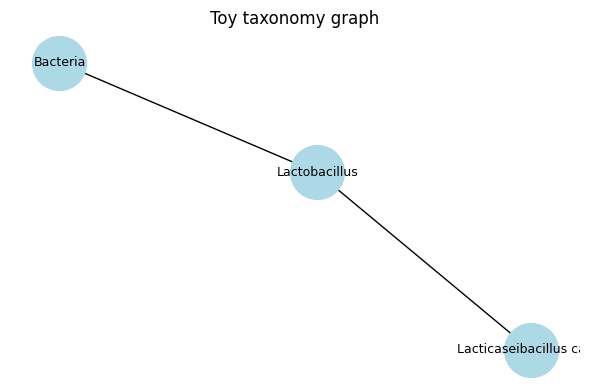

In [107]:
# Draw the toy graph
plt.figure(figsize=(6, 4))
pos = nx.spring_layout(G_toy, seed=42)  # compute node positions

nx.draw_networkx_nodes(G_toy, pos, node_color='lightblue', node_size=1500)
nx.draw_networkx_edges(G_toy, pos, arrows=True, arrowsize=20)
nx.draw_networkx_labels(G_toy, pos, font_size=9)

plt.title("Toy taxonomy graph")
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Step 4 – Build the habitat ontology graph

Now let's turn the habitat `is_a_habitat` triples into a real NetworkX directed graph.  
In this graph:
- Each **node** is a habitat ID
- Each **edge** goes from **parent → child** (following the normal ontology convention where edges point from general to specific)

In [108]:
def build_directed_graph_from_triples(triples):
    """
    Build a directed graph from a list of (head, relation, tail) triples.
    Each triple is structured as (child, relation, parent).
    We add edges from tail → head, which means parent → child (normal ontology direction).
    This allows descendants to be reached by following edges forward.
    """
    G = nx.DiGraph()

    for head, relation, tail in tqdm(triples, desc="Adding edges"):
        # tail is the parent, head is the child
        # We add an edge from parent to child
        G.add_edge(tail, head, relation=relation)

    return G


# Build the habitat ontology graph
G_H_raw = build_directed_graph_from_triples(triples_H)

print("Habitat graph before pruning:")
print(f"  Nodes (unique habitat IDs): {G_H_raw.number_of_nodes()}")
print(f"  Edges (is_a relationships): {G_H_raw.number_of_edges()}")
print(f"  Is DAG: {nx.is_directed_acyclic_graph(G_H_raw)}")

# Prune cycles before exploring descendants (important for cheese-related subgraph extraction)
G_H = prune_to_dag_by_scc(G_H_raw)

print("\nHabitat graph after pruning:")
print(f"  Nodes (unique habitat IDs): {G_H.number_of_nodes()}")
print(f"  Edges (is_a relationships): {G_H.number_of_edges()}")
print(f"  Is DAG: {nx.is_directed_acyclic_graph(G_H)}")

Adding edges:   0%|          | 0/4854 [00:00<?, ?it/s]

Adding edges: 100%|██████████| 4854/4854 [00:00<00:00, 438283.64it/s]


Habitat graph before pruning:
  Nodes (unique habitat IDs): 3888
  Edges (is_a relationships): 4854
  Is DAG: False


100%|██████████| 2667/2667 [00:00<00:00, 368027.92it/s]


Habitat graph after pruning:
  Nodes (unique habitat IDs): 3888
  Edges (is_a relationships): 3887
  Is DAG: True


### 4.1 – Find the cheese habitats

We want to find all habitat nodes whose human-readable name contains the word **"cheese"**.  
We use our `habitat_id_to_name` dictionary for that.

In [109]:
# For each node in the habitat graph, look up its name and check for 'cheese'
cheese_nodes = []

for node in G_H.nodes():
    # Get the human-readable name (fall back to the ID if not found)
    name = habitat_id_to_name.get(node, node)
    
    # Check if 'cheese' appears anywhere in the name (case-insensitive)
    if 'cheese' in name.lower():
        cheese_nodes.append(node)

print(f"Found {len(cheese_nodes)} habitat nodes containing 'cheese':")
for node in cheese_nodes:
    print(f"  {node}  →  {habitat_id_to_name.get(node, node)}")

Found 22 habitat nodes containing 'cheese':
  OBT:003494  →  smear ripened cheese
  OBT:003450  →  hard cheese
  OBT:001480  →  cheese
  OBT:003489  →  extra hard cheese
  OBT:003428  →  ripened cheese
  OBT:003458  →  semi soft cheese
  OBT:003459  →  soft cheese
  OBT:001481  →  cheese rind
  OBT:002043  →  fresh cheese
  OBT:003185  →  cheesecake
  OBT:003251  →  cheese factory
  OBT:003486  →  blue veined cheese
  OBT:003432  →  streched curd cheese
  OBT:003381  →  fermented cheese
  OBT:001482  →  cheese smear
  OBT:001944  →  cheese brine
  OBT:003559  →  cream cheese
  OBT:001341  →  surface of cheese
  OBT:002319  →  American cheese
  OBT:001030  →  cheese starter culture
  OBT:003406  →  brined cheese
  OBT:002408  →  cottage cheese


### 4.2 – Find all cheese-related habitats (descendants)

In the habitat ontology, more specific habitats are **descendants** of broader ones.  
For example, "camembert" is a descendant of "cheese".

NetworkX has a built-in function `nx.descendants(G, node)` that returns all nodes reachable from a given node by following edges.

In [110]:
# Collect all descendants of every cheese node
# (these are more specific cheese-related habitats)
cheese_related_nodes = set()  # we use a set to automatically avoid duplicates

for cheese_node in cheese_nodes:
    # Add the cheese node itself
    cheese_related_nodes.add(cheese_node)
    
    # Add all nodes reachable from this cheese node (its descendants)
    descendants = nx.descendants(G_H, cheese_node)
    cheese_related_nodes.update(descendants)

print(f"Total cheese-related habitat nodes (including sub-types): {len(cheese_related_nodes)}")

# Show some examples with their names
print("\nSome examples:")
for node in list(cheese_related_nodes)[:15]:
    print(f"  {node}  →  {habitat_id_to_name.get(node, node)}")

Total cheese-related habitat nodes (including sub-types): 124

Some examples:
  OBT:003479  →  Morbier
  OBT:003495,  →  OBT:003495,
  OBT:003564,  →  OBT:003564,
  OBT:003505,  →  OBT:003505,
  OBT:001030  →  cheese starter culture
  OBT:003467  →  Caciocavallo
  OBT:003489  →  extra hard cheese
  OBT:003522  →  Scimudin
  OBT:003428,  →  OBT:003428,
  OBT:003510  →  Livarot
  OBT:001944  →  cheese brine
  OBT:002570  →  queso fresco
  OBT:003483  →  Valtellina Casera
  OBT:003492  →  OBT:003492
  OBT:003520  →  Saint-Paulin


Cheese ontology subgraph: 124 nodes, 115 edges


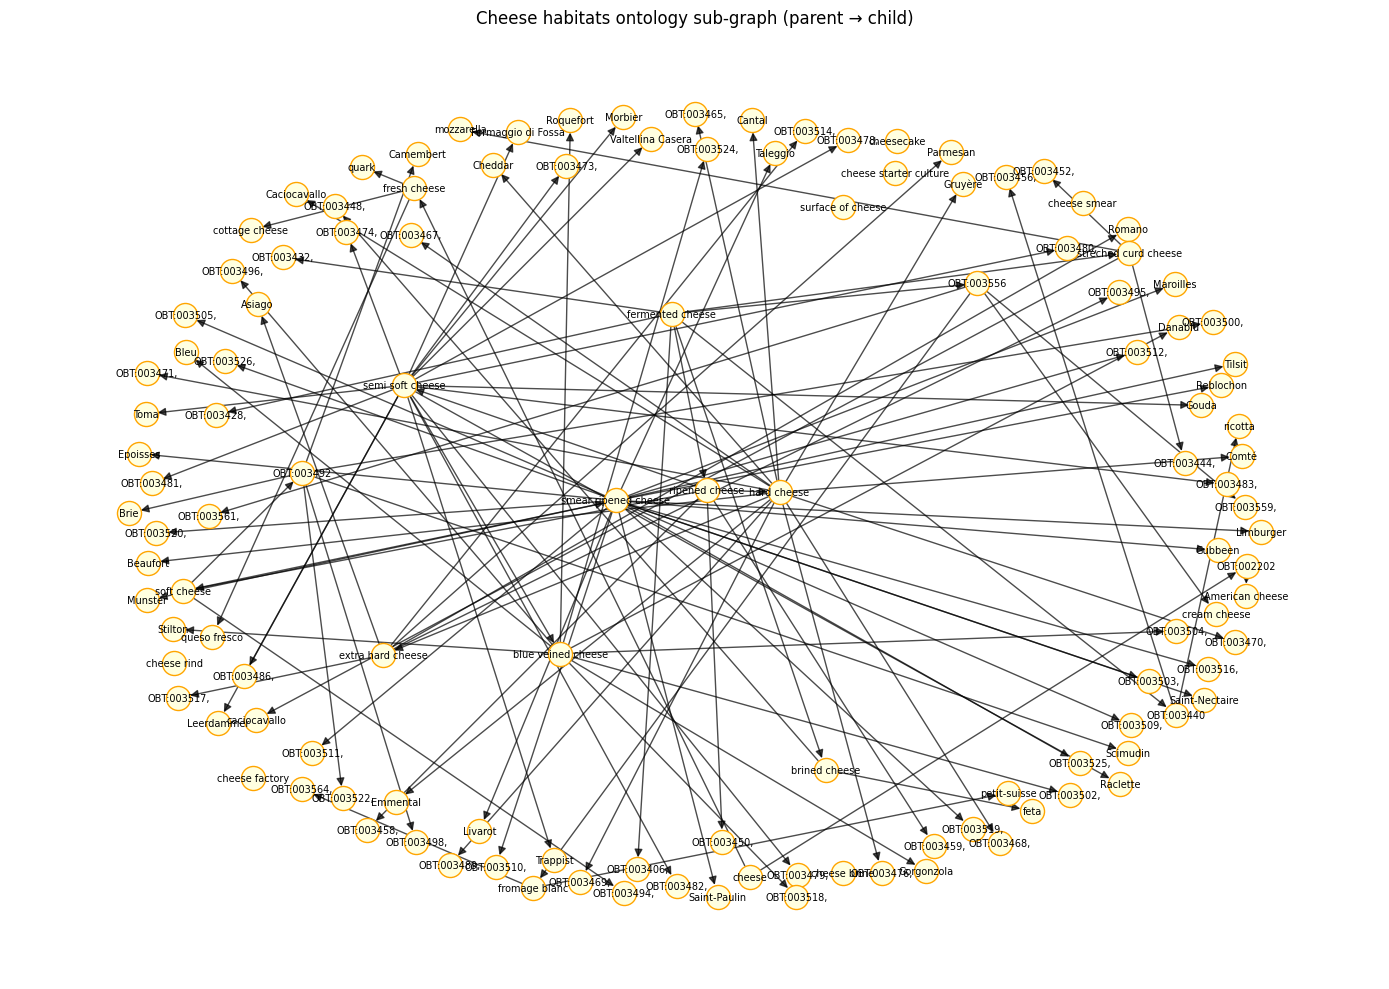

In [111]:
# Build the cheese sub-graph and visualize it
G_cheese_ontology = G_H.subgraph(cheese_related_nodes).copy()

print(f"Cheese ontology subgraph: {G_cheese_ontology.number_of_nodes()} nodes, {G_cheese_ontology.number_of_edges()} edges")

# Draw it
plt.figure(figsize=(14, 10))

# Use hierarchical layout (tries to place nodes in layers)
try:
    pos = nx.nx_agraph.graphviz_layout(G_cheese_ontology, prog='dot')
except Exception:
    # Fall back to spring layout if graphviz is not installed
    pos = nx.spring_layout(G_cheese_ontology, seed=42, k=1.5)

# Use human-readable labels
labels = {node: habitat_id_to_name.get(node, node) for node in G_cheese_ontology.nodes()}

nx.draw_networkx_nodes(G_cheese_ontology, pos, node_size=300, node_color='lightyellow', edgecolors='orange')
nx.draw_networkx_edges(G_cheese_ontology, pos, arrows=True, alpha=0.7, arrowsize=12)
nx.draw_networkx_labels(G_cheese_ontology, pos, labels=labels, font_size=7)

plt.title("Cheese habitats ontology sub-graph (parent → child)")
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Step 5 – Build the habitat-habitat network directly

Instead of creating extra dictionaries, we can do this in two simple moves:
- Build a `networkx` graph directly from `triples_MH` (microbe-habitat links)
- For each microorganism node, use its habitat neighbors to update habitat-habitat weights

This is mathematically equivalent to a bipartite projection, but easier to read.

In [ ]:
# Build a microbe-habitat graph directly from MH triples
microbe_nodes= set()
habitat_nodes = set()
G_MH = nx.Graph()
for head, _, tail in tqdm(triples_MH, desc="Building microbe-habitat graph"):
    G_MH.add_edge(head, tail)
    microbe_nodes.add(head)
    habitat_nodes.add(tail)

print("Microbe-habitat graph summary:")
print(f"  Microorganism nodes: {len(microbe_nodes)}")
print(f"  Habitat nodes:       {len(habitat_nodes)}")
print(f"  MH edges:            {G_MH.number_of_edges()}")

Building microbe-to-habitat map: 100%|██████████| 700450/700450 [00:00<00:00, 1734027.42it/s]

Direct mapping summary:
  Microorganism nodes: 62329
  Habitat nodes:       2986
  MH edges:            700450


### Weighting scheme for habitat pairs

For each microorganism connected to $k$ habitats, we add a contribution of $1/k$ to each pair of habitats in its neighborhood.

This reduces the impact of very generic hub microorganisms that appear in many habitats.

The weight between habitats $h_1$ and $h_2$ is:

$$W(h_1, h_2) = \sum_{m \in \text{shared microbes}} \frac{1}{k_m}$$

where $k_m$ is the number of habitats where microorganism $m$ appears.

In [ ]:
# Compute habitat-habitat weights from microbe neighborhoods in G_MH
edge_weights = {}  # {(hab_a, hab_b): weight, ...}

for microbe in tqdm(microbe_nodes, desc="Computing projection weights"):
    hab_list = [h for h in G_MH.neighbors(microbe) if h in habitat_nodes]
    k = len(hab_list)

    if k < 2:
        continue

    contribution = 1.0 / k
    for i in range(len(hab_list)):
        for j in range(i + 1, len(hab_list)):
            key = tuple(sorted((hab_list[i], hab_list[j])))
            edge_weights[key] = edge_weights.get(key, 0.0) + contribution

print(f"Number of habitat-habitat edges in projection: {len(edge_weights)}")

Computing projection weights: 100%|██████████| 62329/62329 [00:31<00:00, 1949.92it/s] 

Number of habitat-habitat edges in projection: 3106627


In [118]:
# Step 3: build the NetworkX graph from the computed edge weights
G_habitat_proj = nx.Graph()

for (hab_a, hab_b), weight in edge_weights.items():
    G_habitat_proj.add_edge(hab_a, hab_b, weight=weight)

print("Habitat projection graph:")
print(f"  Nodes: {G_habitat_proj.number_of_nodes()}")
print(f"  Edges: {G_habitat_proj.number_of_edges()}")
print(f"  Density: {nx.density(G_habitat_proj):.6f}")

Habitat projection graph:
  Nodes: 2982
  Edges: 3106627
  Density: 0.698955


---
## Step 6 – Explore the edge weight distribution

Before looking at cheese, let's understand the weight distribution across all edges.

Edge weight statistics:
count    3.106627e+06
mean     1.027032e-01
std      1.268108e+00
min      4.578755e-04
25%      1.094008e-03
50%      4.555493e-03
75%      2.386506e-02
max      6.007744e+02
dtype: float64


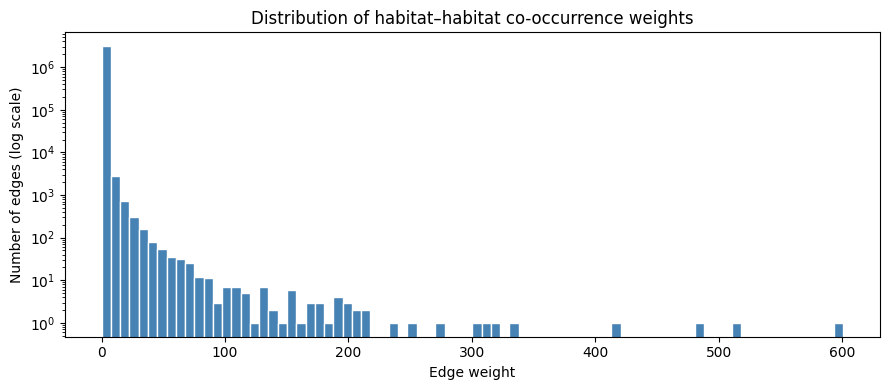

In [119]:
# Collect all edge weights into a list for analysis
all_weights = []
for u, v, data_dict in G_habitat_proj.edges(data=True):
    all_weights.append(data_dict['weight'])

# Basic statistics
weights_series = pd.Series(all_weights)
print("Edge weight statistics:")
print(weights_series.describe())

# Plot a histogram (log scale on y-axis to see the full range)
plt.figure(figsize=(9, 4))
plt.hist(all_weights, bins=80, color='steelblue', edgecolor='white')
plt.yscale('log')  # log scale because most weights are small
plt.xlabel('Edge weight')
plt.ylabel('Number of edges (log scale)')
plt.title('Distribution of habitat–habitat co-occurrence weights')
plt.tight_layout()
plt.show()

In [120]:
# Choose a threshold to keep only the most meaningful edges
# This removes the long tail of very weak (possibly coincidental) connections
threshold = 0.01

# Count how many edges survive the threshold
edges_above = [(u, v, d) for u, v, d in G_habitat_proj.edges(data=True) if d['weight'] > threshold]
pct = len(edges_above) / G_habitat_proj.number_of_edges() * 100
print(f"Edges with weight > {threshold}: {len(edges_above)} ({pct:.1f}% of all edges)")

Edges with weight > 0.01: 1152873 (37.1% of all edges)


In [121]:
# Build the filtered graph keeping only edges above the threshold
G_habitat_filtered = nx.Graph()

for u, v, data_dict in G_habitat_proj.edges(data=True):
    if data_dict['weight'] > threshold:
        G_habitat_filtered.add_edge(u, v, weight=data_dict['weight'])

print("Filtered habitat graph:")
print(f"  Nodes: {G_habitat_filtered.number_of_nodes()}")
print(f"  Edges: {G_habitat_filtered.number_of_edges()}")
print(f"  Density: {nx.density(G_habitat_filtered):.4f}")

Filtered habitat graph:
  Nodes: 2644
  Edges: 1152873
  Density: 0.3300


---
## Step 7 – The cheese sub-graph

Now we intersect the filtered habitat projection graph with the set of cheese-related habitat nodes we found earlier.

In [122]:
# Find cheese-related nodes that also appear in the filtered habitat graph
cheese_in_projection = [
    node
    for node in G_habitat_filtered.nodes()
    if node in cheese_related_nodes
]

print(f"Cheese-related nodes in the projection graph: {len(cheese_in_projection)}")
for node in cheese_in_projection:
    print(f"  {node}  →  {habitat_id_to_name.get(node, node)}")

Cheese-related nodes in the projection graph: 54
  OBT:003452  →  mozzarella
  OBT:002043  →  fresh cheese
  OBT:003458  →  semi soft cheese
  OBT:001480  →  cheese
  OBT:003486  →  blue veined cheese
  OBT:002408  →  cottage cheese
  OBT:002570  →  queso fresco
  OBT:003456  →  ricotta
  OBT:003500  →  Camembert
  OBT:003428  →  ripened cheese
  OBT:003432  →  streched curd cheese
  OBT:003459  →  soft cheese
  OBT:001481  →  cheese rind
  OBT:003494  →  smear ripened cheese
  OBT:003469  →  Cheddar
  OBT:003518  →  Roquefort
  OBT:003450  →  hard cheese
  OBT:003525  →  Taleggio
  OBT:003559  →  cream cheese
  OBT:003504  →  Gorgonzola
  OBT:003512  →  Munster
  OBT:003471  →  Emmental
  OBT:003448  →  feta
  OBT:003496  →  Bleu
  OBT:003474  →  Gouda
  OBT:003498  →  Brie
  OBT:003465  →  Beaufort
  OBT:003406  →  brined cheese
  OBT:003470  →  Comté
  OBT:003467  →  Caciocavallo
  OBT:003514  →  Parmesan
  OBT:003476  →  Gruyère
  OBT:003524  →  Stilton
  OBT:003516  →  Reblochon
 

In [123]:
# Extract the cheese subgraph
G_cheese_proj = G_habitat_filtered.subgraph(cheese_in_projection).copy()

print("Cheese projection sub-graph:")
print(f"  Nodes: {G_cheese_proj.number_of_nodes()}")
print(f"  Edges: {G_cheese_proj.number_of_edges()}")
print(f"  Density: {nx.density(G_cheese_proj):.4f}  (1.0 would be a complete graph)")

Cheese projection sub-graph:
  Nodes: 54
  Edges: 275
  Density: 0.1922  (1.0 would be a complete graph)


---
## Step 8 – Analyse and visualise the cheese graph

### 8.1 – Which cheese habitats are the most connected?

In [124]:
# Compute the weighted degree (strength) of each node:
# sum of the weights of all its edges
node_strength = {}

for node in G_cheese_proj.nodes():
    total_weight = 0.0
    for neighbor in G_cheese_proj.neighbors(node):
        edge_data = G_cheese_proj.get_edge_data(node, neighbor)
        total_weight += edge_data['weight']
    node_strength[node] = total_weight

# Sort by strength and display with human-readable names
sorted_by_strength = sorted(node_strength.items(), key=lambda x: x[1], reverse=True)

print("Top 10 most connected cheese habitats (by weighted degree):")
for node_id, strength in sorted_by_strength[:10]:
    name = habitat_id_to_name.get(node_id, node_id)
    print(f"  {name:40s}  strength = {strength:.4f}")

Top 10 most connected cheese habitats (by weighted degree):
  cheese                                    strength = 17.5430
  smear ripened cheese                      strength = 3.2373
  cheese rind                               strength = 3.1440
  soft cheese                               strength = 2.1105
  ripened cheese                            strength = 1.8837
  cheese brine                              strength = 1.6625
  semi soft cheese                          strength = 1.5171
  Gruyère                                   strength = 1.5124
  Beaufort                                  strength = 1.3873
  blue veined cheese                        strength = 1.3869


### 8.2 – Which pair of cheese habitats is most similar (highest weight)?

In [125]:
# Find the top 10 strongest edges in the cheese subgraph
all_cheese_edges = []
for u, v, data_dict in G_cheese_proj.edges(data=True):
    all_cheese_edges.append((u, v, data_dict['weight']))

# Sort by weight (descending)
all_cheese_edges.sort(key=lambda x: x[2], reverse=True)

print("Top 10 strongest habitat–habitat connections in cheese graph:")
for u, v, w in all_cheese_edges[:10]:
    name_u = habitat_id_to_name.get(u, u)
    name_v = habitat_id_to_name.get(v, v)
    print(f"  {name_u:35s}  ↔  {name_v:35s}   w={w:.4f}")

Top 10 strongest habitat–habitat connections in cheese graph:
  cheese                               ↔  cheese rind                           w=2.2397
  cheese                               ↔  smear ripened cheese                  w=1.8311
  cheese                               ↔  cheese brine                          w=1.5393
  cheese                               ↔  soft cheese                           w=1.2319
  cheese                               ↔  semi soft cheese                      w=1.1427
  cheese                               ↔  blue veined cheese                    w=0.9065
  cheese                               ↔  Beaufort                              w=0.7202
  cheese                               ↔  Cheddar                               w=0.7195
  cheese                               ↔  Gruyère                               w=0.7137
  Beaufort                             ↔  Gruyère                               w=0.6671


### 8.3 – Visualise the cheese graph

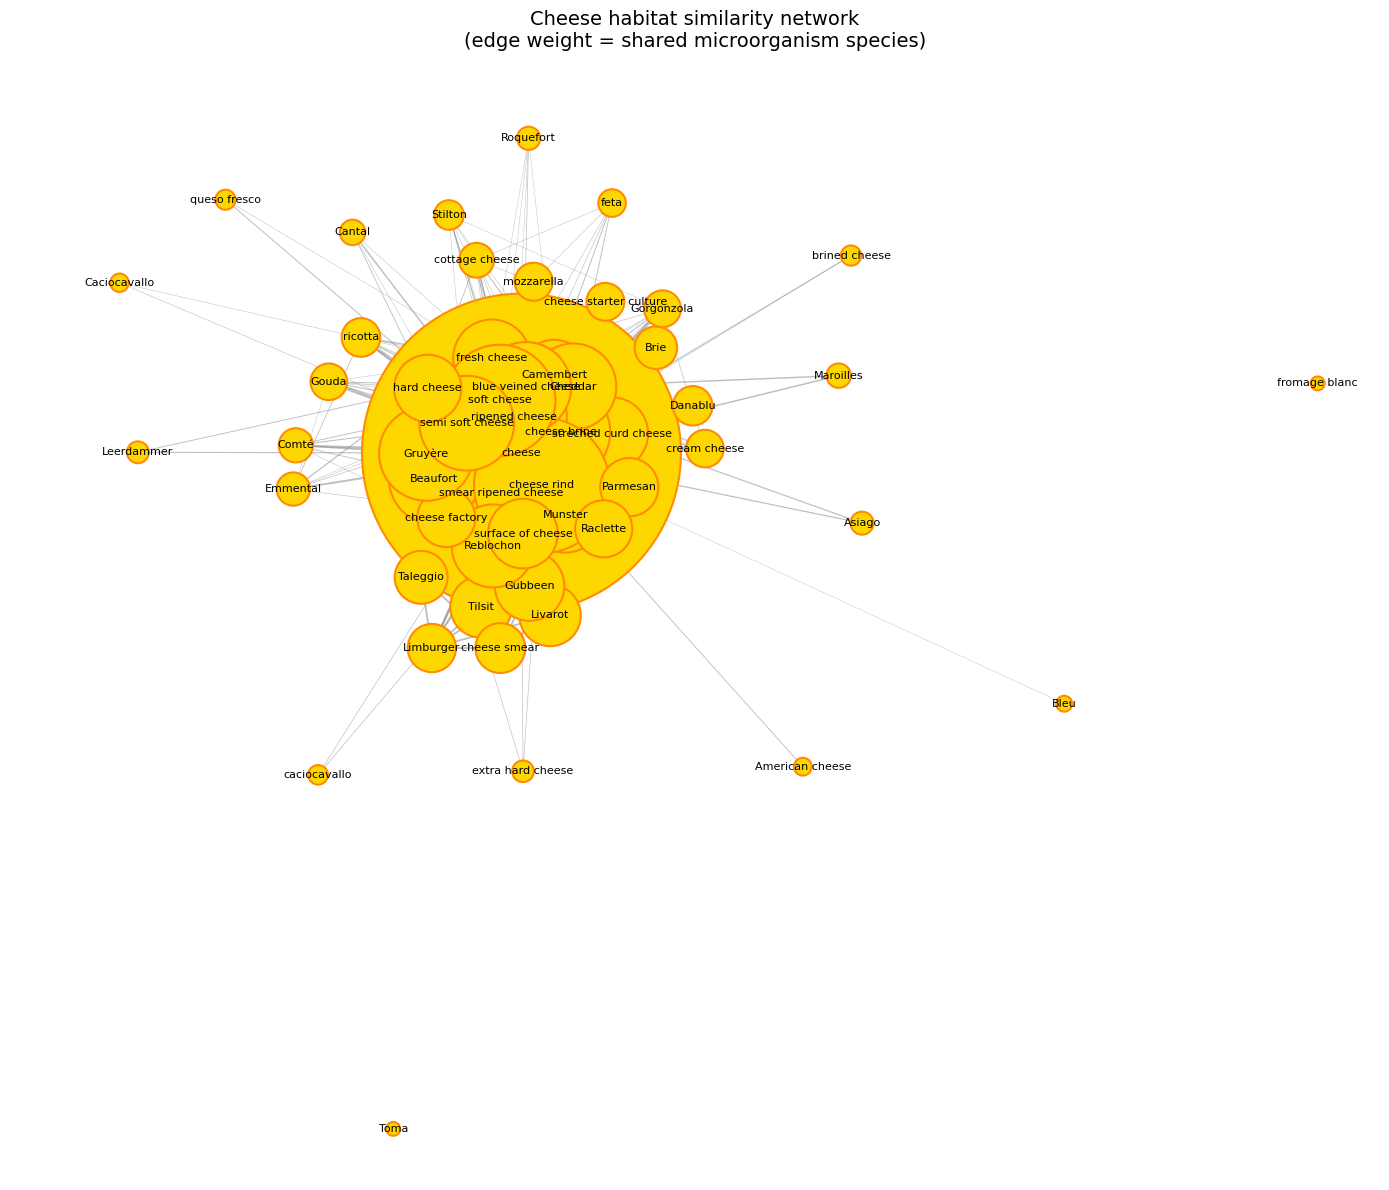

In [126]:
plt.figure(figsize=(14, 12))

# Lay out the nodes using a spring layout weighted by edge weight
# Nodes connected by strong edges will be placed closer together
pos = nx.spring_layout(G_cheese_proj, seed=42, weight='weight')

# Node size proportional to strength
node_sizes = [node_strength.get(node, 0.0) * 3000 + 100 for node in G_cheese_proj.nodes()]

# Edge width proportional to weight
edge_weights_for_drawing = [G_cheese_proj[u][v]['weight'] * 30 for u, v in G_cheese_proj.edges()]

# Human-readable labels
labels = {node: habitat_id_to_name.get(node, node) for node in G_cheese_proj.nodes()}

# Draw everything
nx.draw_networkx_nodes(
    G_cheese_proj, pos,
    node_size=node_sizes,
    node_color='gold',
    edgecolors='darkorange',
    linewidths=1.5
)
nx.draw_networkx_edges(
    G_cheese_proj, pos,
    width=edge_weights_for_drawing,
    alpha=0.5,
    edge_color='gray'
)
nx.draw_networkx_labels(
    G_cheese_proj, pos,
    labels=labels,
    font_size=8
)

plt.title("Cheese habitat similarity network\n(edge weight = shared microorganism species)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Step 9 – Which microorganisms are most associated with cheese?

Using `triples_MH` directly, we ask: which **microorganisms** appear most often across cheese habitats?

In [ ]:
# For each microbe, count in how many distinct cheese-related habitats it appears
from collections import defaultdict

microbe_to_cheese_habitats = defaultdict(set)
for head, _, tail in triples_MH:
    if tail in cheese_related_nodes:
        microbe_to_cheese_habitats[head].add(tail)

microbe_cheese_count = {m: len(habs) for m, habs in microbe_to_cheese_habitats.items()}

# Sort and show the top 20 cheese-associated microbes
top_cheese_mics = sorted(microbe_cheese_count.items(), key=lambda x: x[1], reverse=True)[:20]

print("Top 20 microorganisms most broadly associated with cheese habitats:")
print(f"{'Rank':>4}  {'Name':50s}  {'Cheese habitats':>15}")
print("-" * 75)
for rank, (mic_id, count) in enumerate(top_cheese_mics, start=1):
    name = ncbi_id_to_name.get(mic_id, mic_id)
    print(f"{rank:>4}  {name:50s}  {count:>15}")

Top 20 microorganisms most broadly associated with cheese habitats:
Rank  Name                                                Cheese habitats
---------------------------------------------------------------------------
   1  Bacteria                                                         38
   2  Listeria monocytogenes                                           34
   3  Staphylococcus aureus                                            22
   4  Escherichia coli                                                 19
   5  Listeria                                                         19
   6  Lactococcus lactis                                               18
   7  Lactobacillus                                                    17
   8  Salmonella                                                       14
   9  Lacticaseibacillus paracasei                                     13
  10  Enterococcus                                                     13
  11  Penicillium roqueforti              

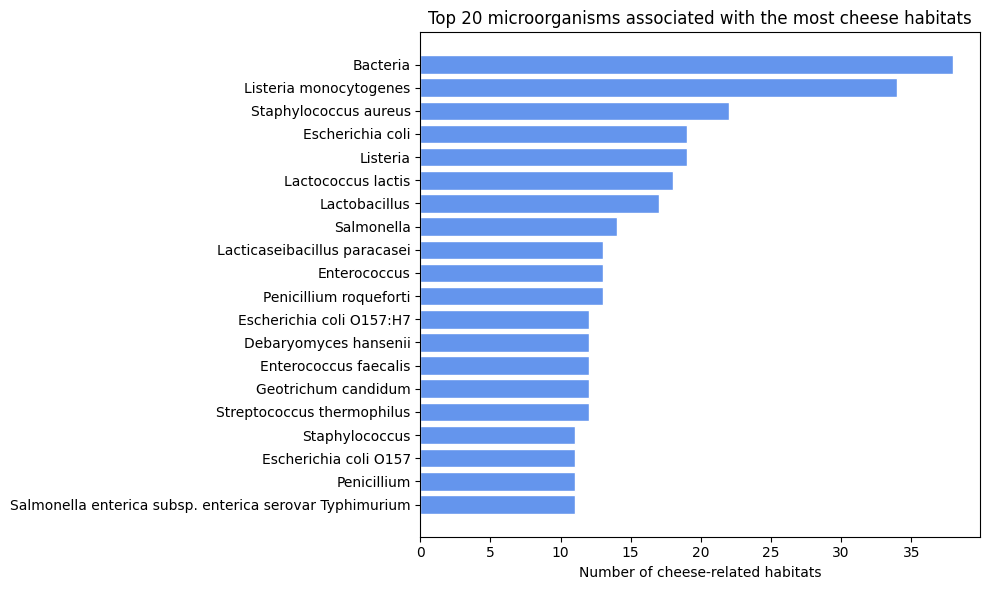

In [128]:
# Visualize the top microbes as a bar chart
top_names  = [ncbi_id_to_name.get(m, m) for m, _ in top_cheese_mics]
top_counts = [c for _, c in top_cheese_mics]

plt.figure(figsize=(10, 6))
plt.barh(top_names[::-1], top_counts[::-1], color='cornflowerblue', edgecolor='white')
plt.xlabel('Number of cheese-related habitats')
plt.title('Top 20 microorganisms associated with the most cheese habitats')
plt.tight_layout()
plt.show()

---
## Exercises

Try to solve these on your own (solutions are below, but try first!).

---

### Exercise 1 – Most popular habitat overall

Using `triples_MH`, find the **top 5 habitats** that appear most often across all microorganism–habitat associations (regardless of taxonomic rank).

*Hint*: count the occurrences of the `tail` element in each triple.

In [ ]:
# Your code here

---

### Exercise 2 – Milk habitats network

Repeat what we did for cheese, but for habitats whose name contains **"milk"**.

1. Find all milk-related habitat nodes from `G_H`
2. Extract the milk projection subgraph from `G_habitat_filtered`
3. Visualise it

In [ ]:
# Your code here

---

### Exercise 3 – Do cheese and milk share microorganisms?

Are there microorganisms that appear in *both* cheese-related habitats *and* milk-related habitats?  
Find them and print their names.

*Hint*: work directly from `triples_MH` and build, for each microorganism, the set of habitats where it appears.

In [ ]:
# Your code here

---

### Exercise 4 – Change the threshold

In Step 6 we chose `threshold = 0.005`. Rebuild `G_habitat_filtered` with a **higher** threshold (e.g. 0.05) and a **lower** one (e.g. 0.001).  
How does the density of `G_cheese_proj` change?

*Think about it*: what is the risk of using a threshold that is too low? Too high?

In [ ]:
# Your code here

---

## Solutions

<details>
<summary>Click to reveal solutions</summary>

### Solution – Exercise 1

```python
habitat_counts = Counter(tail for _, _, tail in triples_MH)
for hab_id, count in habitat_counts.most_common(5):
    print(f"{habitat_id_to_name.get(hab_id, hab_id):40s}  {count} times")
```

### Solution – Exercise 2

```python
milk_nodes = []
for node in G_H.nodes():
    name = habitat_id_to_name.get(node, node)
    if 'milk' in name.lower():
        milk_nodes.append(node)

milk_related_nodes = set(milk_nodes)
for m in milk_nodes:
    milk_related_nodes.update(nx.descendants(G_H, m))
    milk_related_nodes.add(m)

milk_in_proj = [n for n in G_habitat_filtered.nodes() if n in milk_related_nodes]
G_milk_proj  = G_habitat_filtered.subgraph(milk_in_proj).copy()
print(G_milk_proj)

# visualise with the same code as cheese
```

### Solution – Exercise 3

```python
from collections import defaultdict

microbe_to_habs = defaultdict(set)
for head, _, tail in triples_MH:
    microbe_to_habs[head].add(tail)

shared_mics = []
for microbe, hab_set in microbe_to_habs.items():
    in_cheese = any(h in cheese_related_nodes for h in hab_set)
    in_milk   = any(h in milk_related_nodes   for h in hab_set)
    if in_cheese and in_milk:
        shared_mics.append(microbe)

print(f"{len(shared_mics)} microorganisms found in both cheese and milk habitats")
for m in shared_mics[:10]:
    print(f"  {ncbi_id_to_name.get(m, m)}")
```

### Solution – Exercise 4

```python
for thr in [0.001, 0.005, 0.05]:
    G_filt = nx.Graph()
    for u, v, d in G_habitat_proj.edges(data=True):
        if d['weight'] > thr:
            G_filt.add_edge(u, v, weight=d['weight'])

    cheese_sub_nodes = [n for n in G_filt.nodes() if n in cheese_related_nodes]
    G_cheese_sub = G_filt.subgraph(cheese_sub_nodes).copy()

    print(f"threshold={thr}  ->  cheese nodes: {G_cheese_sub.number_of_nodes()},  "
          f"edges: {G_cheese_sub.number_of_edges()},  "
          f"density: {nx.density(G_cheese_sub):.4f}")
```

</details>

---

## Summary

Congratulations! In this lesson you have:

1. **Loaded** a real biological knowledge graph dataset from a TSV file
2. **Built triples** of three types: microbe-habitat, organism taxonomy, habitat ontology
3. **Created directed graphs** from those triples with NetworkX
4. **Navigated an ontology** to find all cheese-related habitat nodes
5. **Computed habitat-habitat weights directly from MH triples**
6. **Constructed** a habitat-habitat similarity network using degree-normalized weights ($1/k$)
7. **Filtered edges** by weight to keep only strong connections
8. **Analysed** the cheese sub-network: density, most connected nodes, strongest pairs
9. **Identified** which microorganisms are most broadly associated with cheese habitats